# HW2 — Filtering & Image Quality Enhancement

**Plan:**
1. Import the finished HW1 pipeline from `main.py` and run it as the baseline.
2. Try new stages from module_2 (Lessons 3 & 4) on top of the baseline.
3. Once a combination beats the baseline, copy the final params into `main_task2.py`.

**New stages we'll experiment with:**
- *Lesson 3 (filtering):* `median_blur`, `bilateral`, `sharpen`, `average_filter`
- *Lesson 4 (brightness/contrast):* `log_transform`, `pow_transform` (gamma), `hist_stretch`, `hist_slide`

## 1. Setup — import HW1 pipeline as baseline

In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Everything we built in HW1
from main import (
    BING_PATH, LANDSAT_PATH,
    PARAMS_BING, PARAMS_LANDSAT,
    STAGES, run_pipeline,
    show_originals, show_pipeline_grid, show_contours_side_by_side,
)

bing    = cv2.imread(str(BING_PATH),    cv2.IMREAD_COLOR)
landsat = cv2.imread(str(LANDSAT_PATH), cv2.IMREAD_COLOR)
print('bing   ', bing.shape)
print('landsat', landsat.shape)

bing    (551, 752, 3)
landsat (609, 762, 3)


## 2. Baseline — run HW1 pipeline as-is

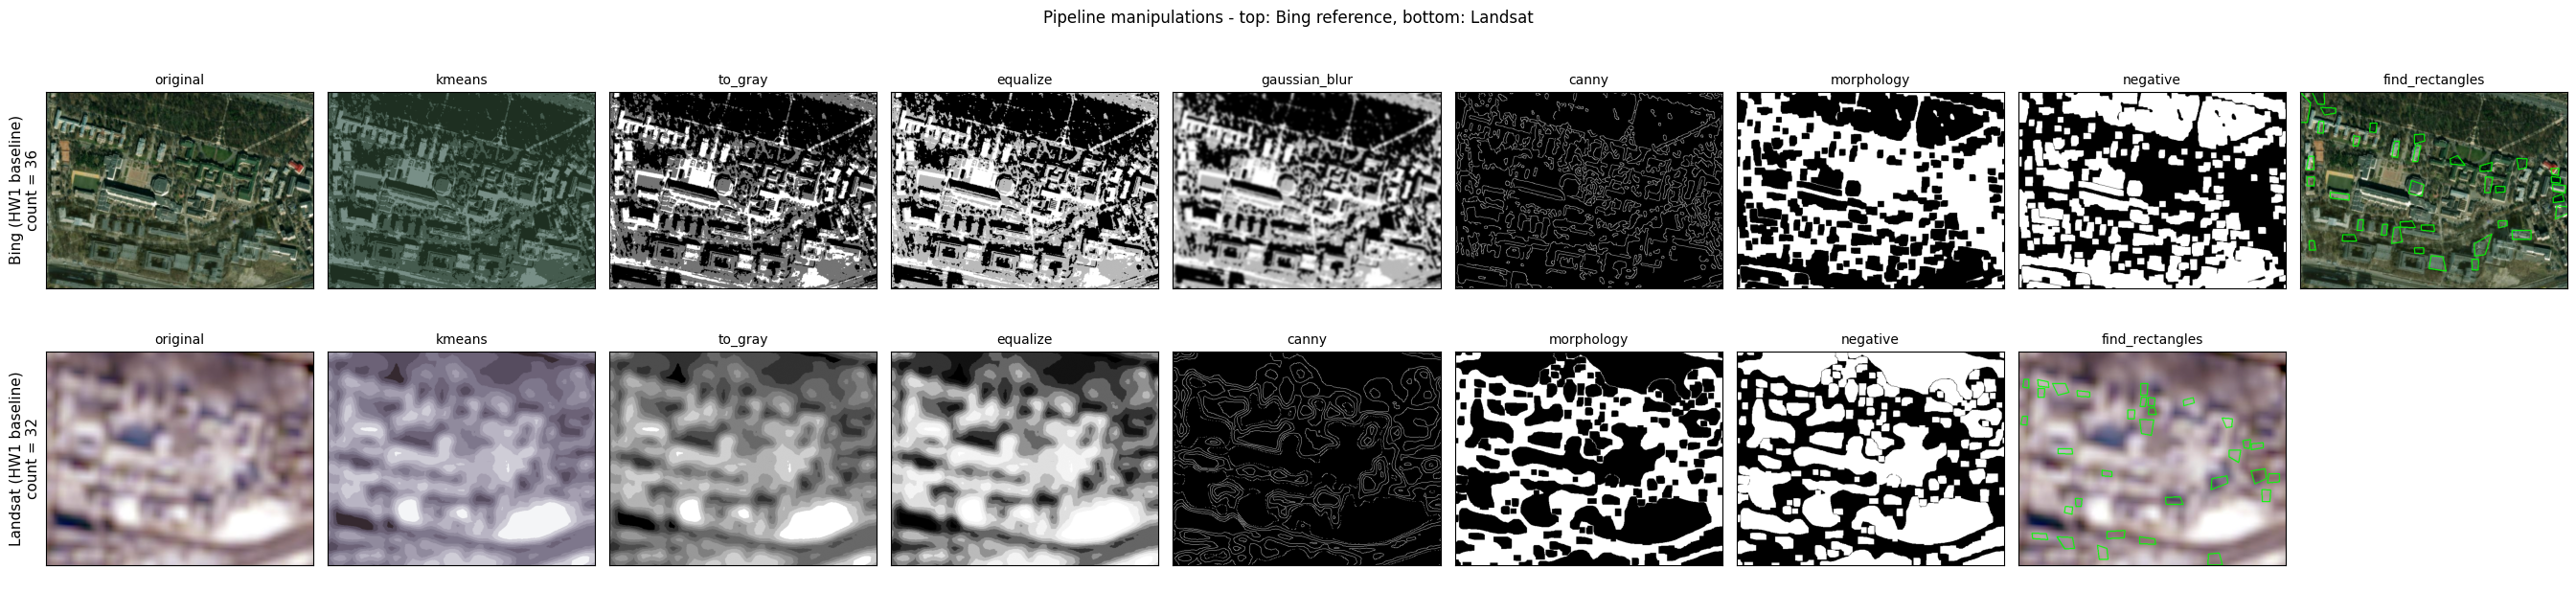

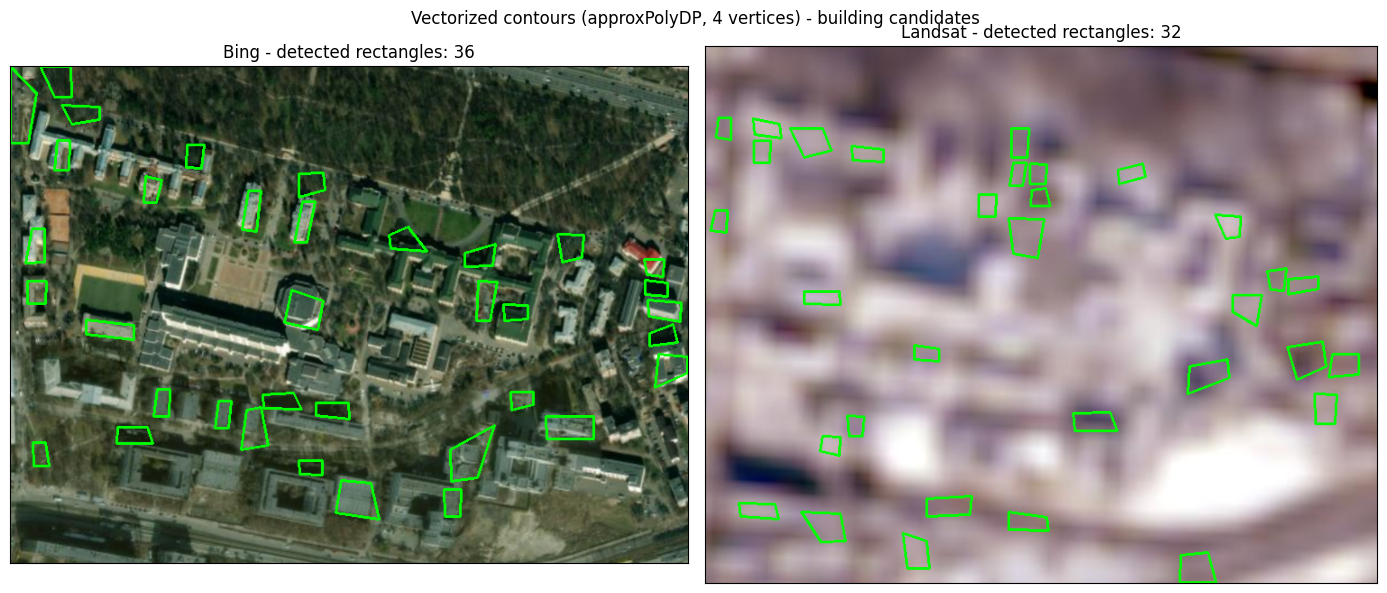

baseline   bing=36  landsat=32  delta=-4


In [2]:
snaps_b, ctx_b = run_pipeline(bing,    PARAMS_BING)
snaps_l, ctx_l = run_pipeline(landsat, PARAMS_LANDSAT)

show_pipeline_grid(snaps_b, snaps_l, ctx_b['count'], ctx_l['count'],
                   'Bing (HW1 baseline)', 'Landsat (HW1 baseline)')
show_contours_side_by_side(ctx_b, ctx_l)

BASELINE_BING    = ctx_b['count']
BASELINE_LANDSAT = ctx_l['count']
print(f"baseline   bing={BASELINE_BING}  landsat={BASELINE_LANDSAT}  delta={BASELINE_LANDSAT-BASELINE_BING:+d}")

## 3. New stages from module_2 — register into STAGES

Define each new stage inline so we can tweak it without restarting. They get added to the same `STAGES` dict that `run_pipeline` uses, so we can drop them into a pipeline by name.

In [3]:
# --- Lesson 3: filtering ---
def s_median_blur(img, p, ctx):
    return cv2.medianBlur(img, p.get('ksize', 5)), ctx

def s_bilateral(img, p, ctx):
    return cv2.bilateralFilter(img,
                               p.get('d', 9),
                               p.get('sigma_color', 75),
                               p.get('sigma_space', 75)), ctx

def s_sharpen(img, p, ctx):
    a = p.get('amount', 1.0)
    kernel = np.array([[ 0, -1,  0],
                       [-1, 4+a, -1],
                       [ 0, -1,  0]], dtype=np.float32) / max(a, 1e-6)
    return cv2.filter2D(img, -1, kernel), ctx

def s_average_filter(img, p, ctx):
    k = p.get('ksize', 5)
    kernel = np.ones((k, k), np.float32) / (k * k)
    return cv2.filter2D(img, -1, kernel), ctx

# --- Lesson 4: brightness / contrast ---
def s_log_transform(img, p, ctx):
    """s = c * log(1 + r). Brightens dark regions, compresses highlights."""
    c = p.get('c', 255.0 / np.log(1 + 255))
    out = c * np.log1p(img.astype(np.float32))
    return np.clip(out, 0, 255).astype(np.uint8), ctx

def s_pow_transform(img, p, ctx):
    """Gamma: s = c * r^gamma. gamma<1 brightens, gamma>1 darkens."""
    gamma = p.get('gamma', 1.0)
    c = p.get('c', 1.0)
    norm = img.astype(np.float32) / 255.0
    out = c * np.power(norm, gamma) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8), ctx

def s_hist_stretch(img, p, ctx):
    """Linear stretch: remap [low_pct, high_pct] percentiles to [0, 255]."""
    lo = np.percentile(img, p.get('low_pct', 2))
    hi = np.percentile(img, p.get('high_pct', 98))
    if hi <= lo:
        return img, ctx
    out = np.clip((img.astype(np.float32) - lo) * 255.0 / (hi - lo), 0, 255)
    return out.astype(np.uint8), ctx

def s_hist_slide(img, p, ctx):
    """Additive brightness shift."""
    out = img.astype(np.int16) + p.get('shift', 30)
    return np.clip(out, 0, 255).astype(np.uint8), ctx

# Register all new stages into the same registry used by run_pipeline
STAGES.update({
    'median_blur':    s_median_blur,
    'bilateral':      s_bilateral,
    'sharpen':        s_sharpen,
    'average_filter': s_average_filter,
    'log_transform':  s_log_transform,
    'pow_transform':  s_pow_transform,
    'hist_stretch':   s_hist_stretch,
    'hist_slide':     s_hist_slide,
})
list(STAGES)

['to_gray',
 'equalize',
 'negative',
 'gaussian_blur',
 'kmeans',
 'threshold',
 'canny',
 'morphology',
 'find_rectangles',
 'median_blur',
 'bilateral',
 'sharpen',
 'average_filter',
 'log_transform',
 'pow_transform',
 'hist_stretch',
 'hist_slide']

## 4. Try a stage in isolation

Helper to see what each new filter does to one image before plugging it into the pipeline.

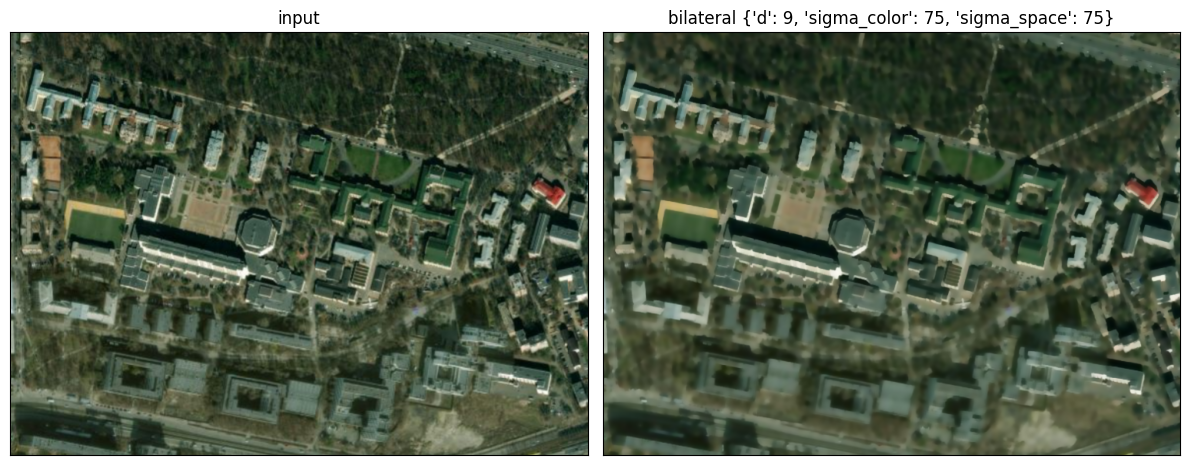

In [5]:
def try_stage(img_bgr, stage_name, params):
    fn = STAGES[stage_name]
    out, _ = fn(img_bgr, params, {'original_bgr': img_bgr.copy()})
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); ax[0].set_title('input')
    ax[1].imshow(out, cmap='gray') if out.ndim == 2 else ax[1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax[1].set_title(f'{stage_name} {params}')
    for a in ax: a.set_xticks([]); a.set_yticks([])
    fig.tight_layout(); plt.show()
    return out

_ = try_stage(bing, 'bilateral', {'d': 9, 'sigma_color': 75, 'sigma_space': 75})

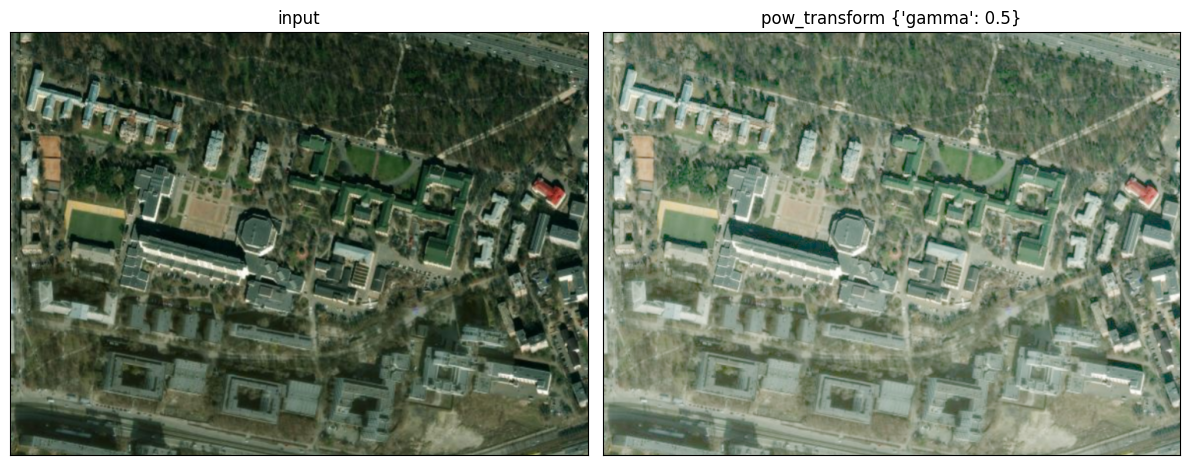

In [7]:
_ = try_stage(bing, 'pow_transform', {'gamma': 0.5})  # gamma<1 brightens

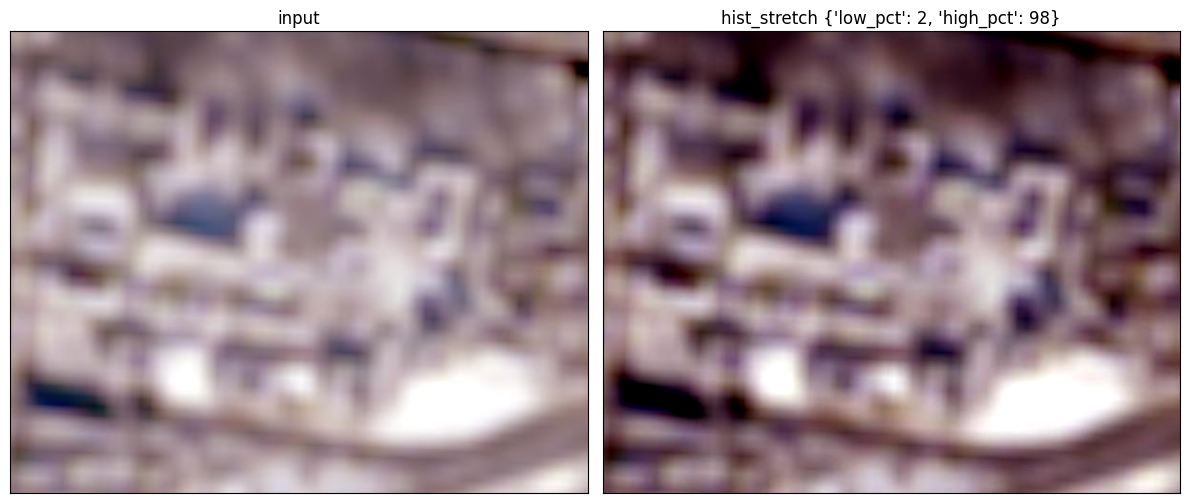

In [8]:
_ = try_stage(landsat, 'hist_stretch', {'low_pct': 2, 'high_pct': 98})

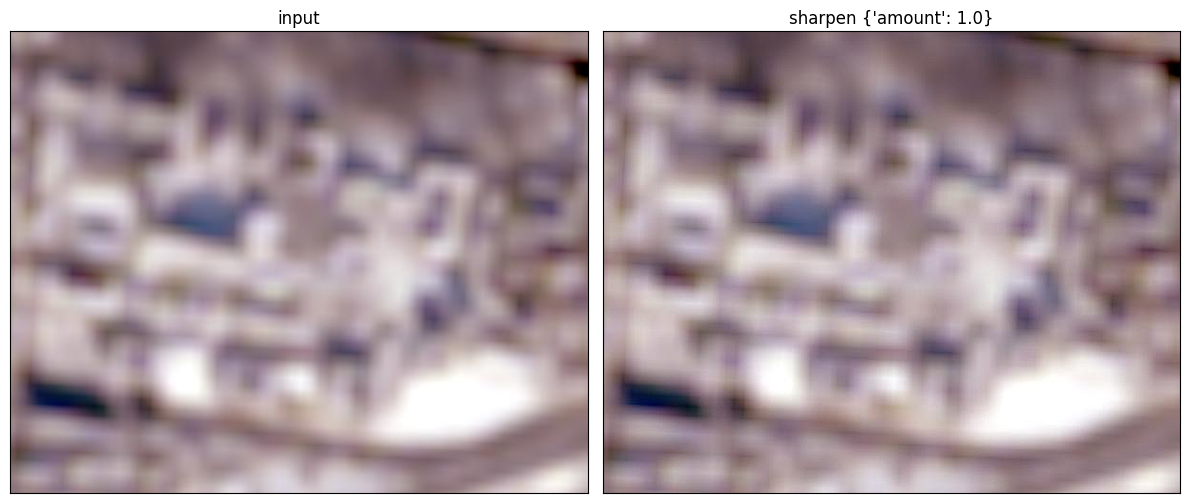

In [10]:
_ = try_stage(landsat, 'sharpen', {'amount': 1.0})

## 5. Candidate pipelines — iterate here

Edit `CANDIDATE_BING` / `CANDIDATE_LANDSAT`, rerun, compare counts to the baseline. When a combination wins, copy it into `main_task2.py`.

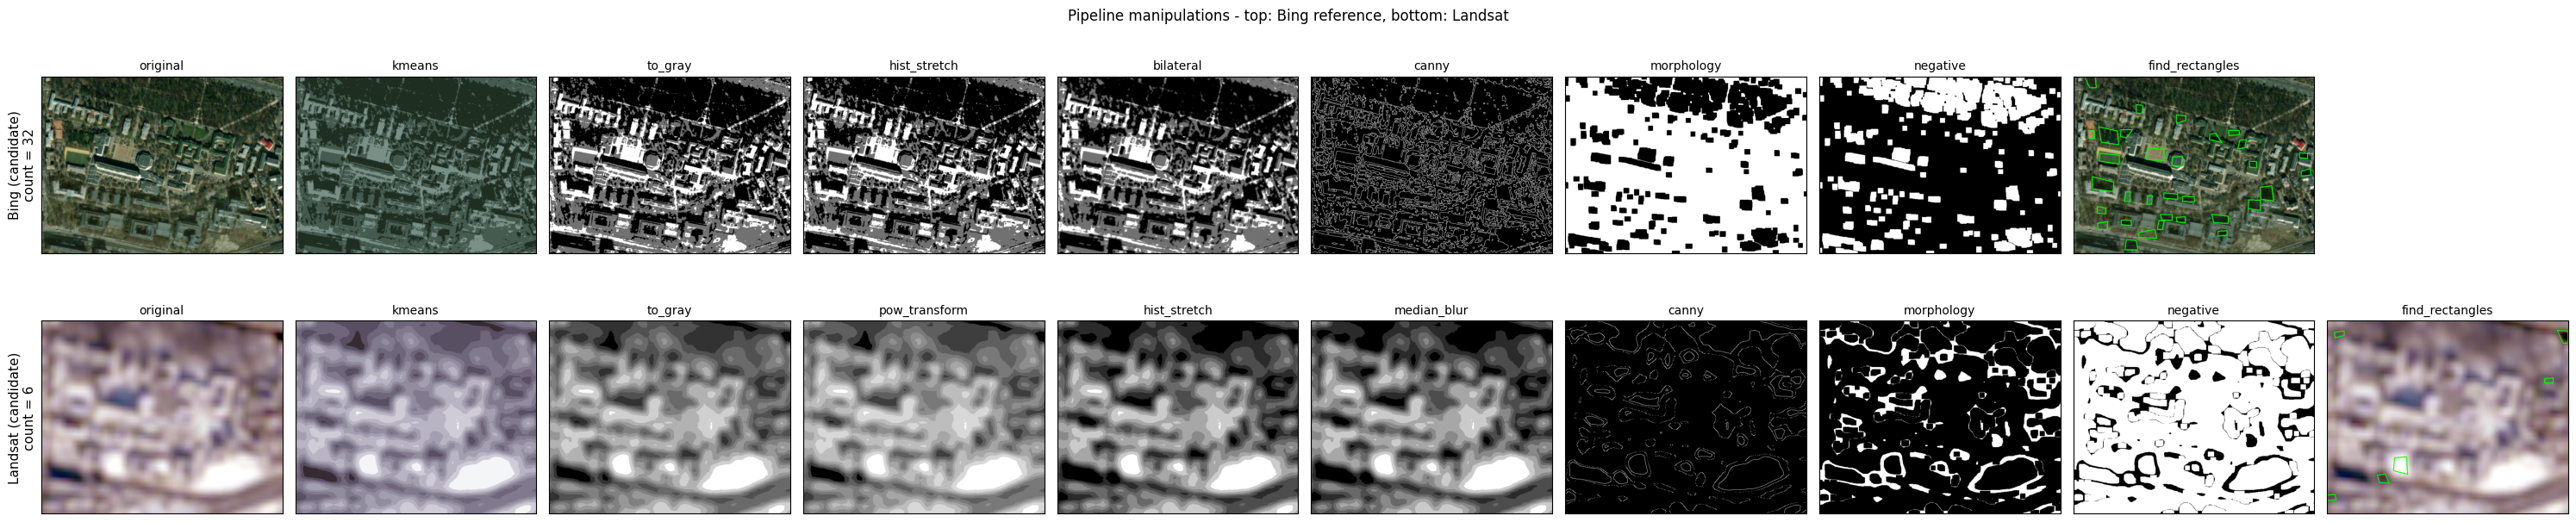

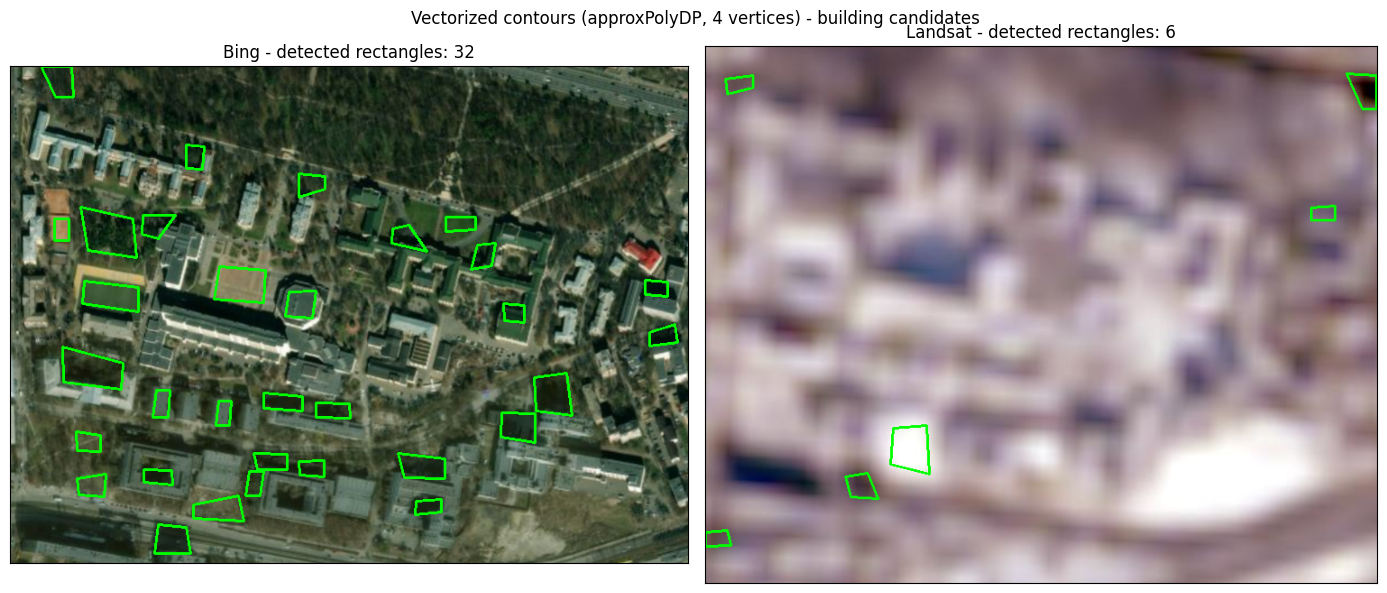

baseline   bing=36  landsat=32
candidate  bing=32  landsat=6
delta      bing=-4  landsat=-26


In [11]:
CANDIDATE_BING = {
    'stages': [
        ('kmeans',          {'K': 3}),
        ('to_gray',         {}),
        ('hist_stretch',    {'low_pct': 2, 'high_pct': 98}),
        ('bilateral',       {'d': 9, 'sigma_color': 75, 'sigma_space': 75}),
        ('canny',           {'low': 50, 'high': 160}),
        ('morphology',      {'op': 'close', 'shape': 'rect', 'ksize': 8, 'iters': 2}),
        ('negative',        {}),
        ('find_rectangles', {'approx_eps': 0.08, 'min_area': 400, 'max_area': 3000,
                             'min_vertices': 4, 'max_vertices': 4}),
    ],
}

CANDIDATE_LANDSAT = {
    'stages': [
        ('kmeans',          {'K': 9}),
        ('to_gray',         {}),
        ('pow_transform',   {'gamma': 0.7}),
        ('hist_stretch',    {'low_pct': 2, 'high_pct': 98}),
        ('median_blur',     {'ksize': 3}),
        ('canny',           {'low': 150, 'high': 200}),
        ('morphology',      {'op': 'close', 'shape': 'rect', 'ksize': 8, 'iters': 2}),
        ('negative',        {}),
        ('find_rectangles', {'approx_eps': 0.08, 'min_area': 400, 'max_area': 3000,
                             'min_vertices': 4, 'max_vertices': 4}),
    ],
}

snaps_b, ctx_b = run_pipeline(bing,    CANDIDATE_BING)
snaps_l, ctx_l = run_pipeline(landsat, CANDIDATE_LANDSAT)
show_pipeline_grid(snaps_b, snaps_l, ctx_b['count'], ctx_l['count'],
                   'Bing (candidate)', 'Landsat (candidate)')
show_contours_side_by_side(ctx_b, ctx_l)

print(f"baseline   bing={BASELINE_BING}  landsat={BASELINE_LANDSAT}")
print(f"candidate  bing={ctx_b['count']}  landsat={ctx_l['count']}")
print(f"delta      bing={ctx_b['count']-BASELINE_BING:+d}  landsat={ctx_l['count']-BASELINE_LANDSAT:+d}")